In [3]:
# Cell 1: Setup
import sys
sys.path.append("..")  # or adjust path if needed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load using your existing functions
from python.load import load_redwood_data, load_mote_location_data, load_dates_data

DATA_PATH = "data"  # adjust if needed

In [4]:
# Cell 2: Load the raw data
redwood_all_orig = load_redwood_data(DATA_PATH, source="all")
motes_orig = load_mote_location_data(DATA_PATH)

print(f"Loaded {len(redwood_all_orig):,} observations")
print(f"Columns: {list(redwood_all_orig.columns)}")

Loaded 416,036 observations
Columns: ['result_time', 'epoch', 'nodeid', 'parent', 'voltage', 'depth', 'humidity', 'humid_temp', 'humid_adj', 'hamatop', 'hamabot']


=== RAW VOLTAGE ===
count    416036.000000
mean         82.733087
std         176.412758
min           0.009063
25%           2.651430
50%           2.749630
75%         214.000000
max        1023.000000
Name: voltage, dtype: float64


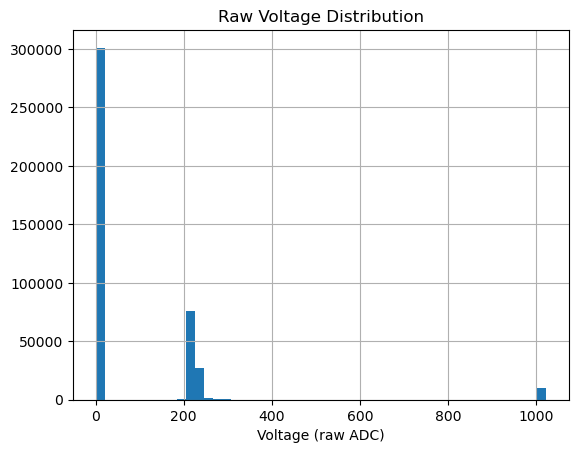

=== FIXED VOLTAGE ===
count    416036.000000
mean          2.074771
std           0.969138
min           0.009063
25%           0.725806
50%           2.651430
75%           2.749630
max           3.300000
Name: voltage_fixed, dtype: float64


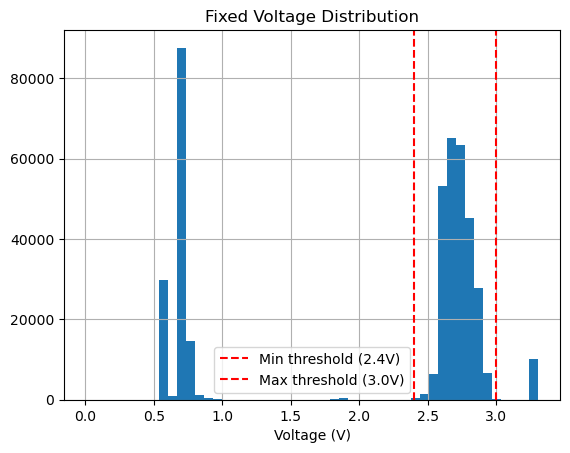

In [6]:
# Cell: Fix the voltage column
def fix_voltage(voltage):
    """
    Some values are already in Volts (0-3.3), 
    others are raw ADC (0-1023). Convert ADC to Volts.
    """
    if voltage > 10:  # Clearly an ADC value, not volts
        return voltage / 1023 * 3.3
    else:  # Already in volts
        return voltage

redwood_all_orig['voltage_fixed'] = redwood_all_orig['voltage'].apply(fix_voltage)

# Check the result
print("=== FIXED VOLTAGE ===")
print(redwood_all_orig['voltage_fixed'].describe())

# Plot
redwood_all_orig['voltage_fixed'].hist(bins=50)
plt.title("Fixed Voltage Distribution")
plt.xlabel("Voltage (V)")
plt.axvline(x=2.4, color='r', linestyle='--', label='Min threshold (2.4V)')
plt.axvline(x=3.0, color='r', linestyle='--', label='Max threshold (3.0V)')
plt.legend()
plt.show()

In [7]:
# How many observations are in the valid range?
valid = (redwood_all_orig['voltage_fixed'] >= 2.4) & (redwood_all_orig['voltage_fixed'] <= 3.0)
print(f"\nValid observations (2.4-3.0V): {valid.sum():,} ({valid.mean()*100:.1f}%)")


Valid observations (2.4-3.0V): 270,328 (65.0%)
